### Week 1 — Data Loading, EDA & Preprocessing
#### AI Demand Forecasting - Store Sales Time Series

#### 📌 Flow 
1. Impoer Libraries
2. Load all Dataset files
3. Missing valuse check
4. Exploratory data Analysis(EDA)
5. Train / Validation / Test

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')


In [3]:
# Load All Dataset file
train_df = pd.read_csv(r"C:\Users\user\Documents\Food & Restaurant Services\train.csv")
test_df= pd.read_csv(r"C:\Users\user\Documents\Food & Restaurant Services\test.csv")
stores_df = pd.read_csv(r"C:\Users\user\Documents\Food & Restaurant Services\stores.csv")
oil_df = pd.read_csv(r"C:\Users\user\Documents\Food & Restaurant Services\oil.csv")
hol_df = pd.read_csv(r"C:\Users\user\Documents\Food & Restaurant Services\holidays_events.csv")
txn_df = pd.read_csv(r"C:\Users\user\Documents\Food & Restaurant Services\transactions.csv")
s_sub_df = pd.read_csv(r"C:\Users\user\Documents\Food & Restaurant Services\sample_submission.csv")


files = {
    'train.csv'           : train_df,
    'test.csv'            : test_df,
    'stores.csv'          : stores_df,
    'oil.csv'             : oil_df,
    'holidays_events.csv' : hol_df,
    'transactions.csv'    : txn_df,
    'sample_submission.csv': s_sub_df,
}


# ---------- Explicitly convert date columns to datetime ----------
# parse_dates in newer pandas versions can silently fail — this is safer
for _df, _col in [(train_df,'date'),(test_df,'date'),(oil_df,'date'),
                  (hol_df,'date'),(txn_df,'date')]:
    _df[_col] = pd.to_datetime(_df[_col])

print(f"{'file':<28}{'Rows':>8} {'Cols':>5}")
print('-' * 45)

for name, df in files.items():
    print(f"{name:<28} {df.shape[0]:>8,} {df.shape[1]:>5}")


print(f"\nTrain date range : {train_df['date'].min().date()}  {train_df['date'].max().date()}")
print(f"Test date range : {test_df['date'].min().date()} {test_df['date'].max().date()} ")


file                            Rows  Cols
---------------------------------------------
train.csv                    3,000,888     6
test.csv                       28,512     5
stores.csv                         54     5
oil.csv                         1,218     2
holidays_events.csv               350     6
transactions.csv               83,488     3
sample_submission.csv          28,512     2

Train date range : 2013-01-01  2017-08-15
Test date range : 2017-08-16 2017-08-31 


#### Inspect each file

In [4]:
# train file
display(train_df.head())
print('Unique stores :', train_df['store_nbr'].nunique())
print('Unique families :', train_df['family'].nunique())
print('Unique list :', sorted(train_df['family'].unique()))

print('Target Variable -- sales -- Statistics:')
display(train_df['sales'].describe().round(2).to_frame())
zero_pct = (train_df['sales'] == 0).mean() * 100
print(f' \nRows with zore  sales  : {(train_df["sales"]==0).sum():,}({zero_pct:.1f}%)')
print(' Zero sales = Store closed or product not stocked that day')


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


Unique stores : 54
Unique families : 33
Unique list : ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']
Target Variable -- sales -- Statistics:


,sales
count,3000888.00
mean,357.78
std,1102.00
min,0.00
25%,0.00
50%,11.00
75%,195.85
max,124717.00


 
Rows with zore  sales  : 939,130(31.3%)
 Zero sales = Store closed or product not stocked that day


In [5]:
# Stores file
display(stores_df.head(5))
print('Store types    :', sorted(stores_df['type'].unique()))
print('Store clusters :', sorted(stores_df['cluster'].unique()))
print('Cities         :', stores_df['city'].nunique(), 'unique cities')
print('States         :', stores_df['state'].nunique(), 'unique states')

# Holidays_events file
display(hol_df.head(5))
print('Holiday types :', hol_df['type'].unique())
print('Locale types :', hol_df['locale'].unique())
print('Transferred rows:', hol_df['transferred'].unique())

# Oil file
display(oil_df.head(8))
print('Date range:', oil_df['date'].min().date(), '→', oil_df['date'].max().date())
print('Missing oil prices:', oil_df['dcoilwtico'].isnull().sum(), 'rows')
print('(Missing = weekends/holidays when oil market is closed)')

# Transactions file
display(txn_df.head(8))
print('Transactions stats:')
display(txn_df['transactions'].describe().round(0).to_frame())


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


Store types    : ['A', 'B', 'C', 'D', 'E']
Store clusters : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
Cities         : 22 unique cities
States         : 16 unique states


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


Holiday types : ['Holiday' 'Transfer' 'Additional' 'Bridge' 'Work Day' 'Event']
Locale types : ['Local' 'Regional' 'National']
Transferred rows: [False  True]


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
5,2013-01-08,93.21
6,2013-01-09,93.08
7,2013-01-10,93.81


Date range: 2013-01-01 → 2017-08-31
Missing oil prices: 43 rows
(Missing = weekends/holidays when oil market is closed)


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
5,2013-01-02,5,1903
6,2013-01-02,6,2143
7,2013-01-02,7,1874


Transactions stats:


,transactions
count,83488.0
mean,1695.0
std,963.0
min,5.0
25%,1046.0
50%,1393.0
75%,2079.0
max,8359.0


In [6]:
# Missing Value Check
print('Missing valuse in each file')
print('=' * 40)

for name, df in files.items():
    missing = df.isnull().sum()
    total = missing.sum()
    if total > 0:
        print(f'\n⚠️ {name}')
        print(missing[missing > 0].to_string())
    else:
        print(f'✅ {name:<28} - no missing Valuse')

#  Fix oil - forward fill weekend gaps
print('\n--- Fixing oil.csv missing values ---')
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].interpolate(method='linear')
print(f'Missing after interpolation: {oil_df["dcoilwtico"].isnull().sum()}')
print('✅ Oil prices fixed using linear interpolation')

Missing valuse in each file
✅ train.csv                    - no missing Valuse
✅ test.csv                     - no missing Valuse
✅ stores.csv                   - no missing Valuse

⚠️ oil.csv
dcoilwtico    43
✅ holidays_events.csv          - no missing Valuse
✅ transactions.csv             - no missing Valuse
✅ sample_submission.csv        - no missing Valuse

--- Fixing oil.csv missing values ---
Missing after interpolation: 1
✅ Oil prices fixed using linear interpolation


### 📊 — Exploratory Data Analysis (EDA)


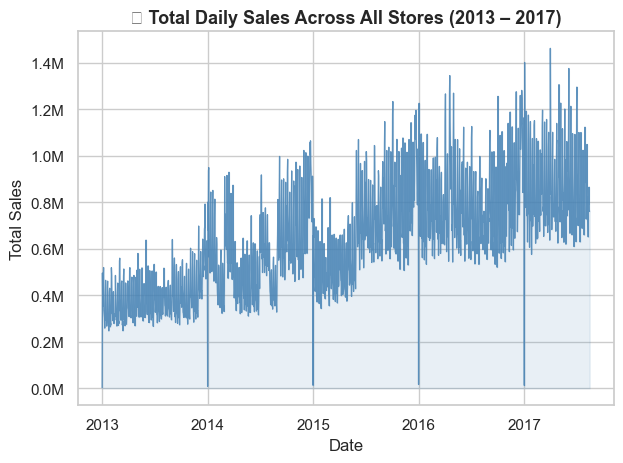

In [7]:
daily_sales = train_df.groupby('date')['sales'].sum().reset_index()

plt.Figure(figsize=(15, 4))
plt.plot(daily_sales['date'],daily_sales['sales'],
         color='steelblue', linewidth=0.9, alpha=0.85)
plt.fill_between(daily_sales['date'],daily_sales['sales'],
                 alpha =0.12, color='steelblue')
plt.title('📈 Total Daily Sales Across All Stores (2013 – 2017)',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
os.makedirs('data/processed', exist_ok=True)
plt.savefig('data/processed/daily_sales_trend.png', dpi=100, bbox_inches='tight')
plt.show()



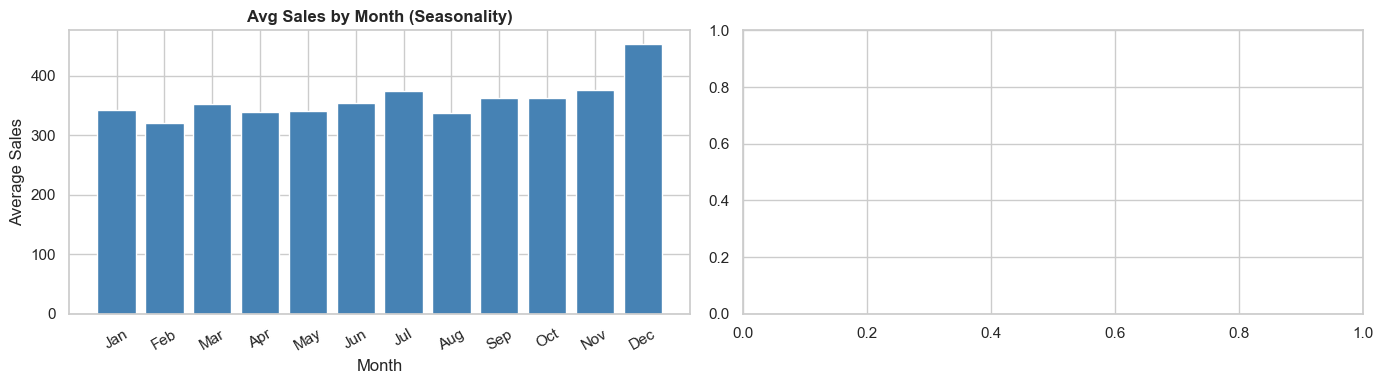

In [8]:
#  Monthly Seasonality
train_df['month'] = train_df['date'].dt.month
train_df['year'] = train_df['date'].dt.year
train_df['dayofweek'] = train_df['date'].dt.dayofweek

monthly_avg = train_df.groupby('month')['sales'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['month_name'] = monthly_avg['month'].apply(lambda x: month_names[x-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly pattern
axes[0].bar(monthly_avg['month_name'],monthly_avg['sales'],
            color ='steelblue', edgecolor = 'white')
axes[0].set_title('Avg Sales by Month (Seasonality)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Sales')
axes[0].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('data/processed/seasonality_patterns.png', dpi=100, bbox_inches='tight')
plt.show()


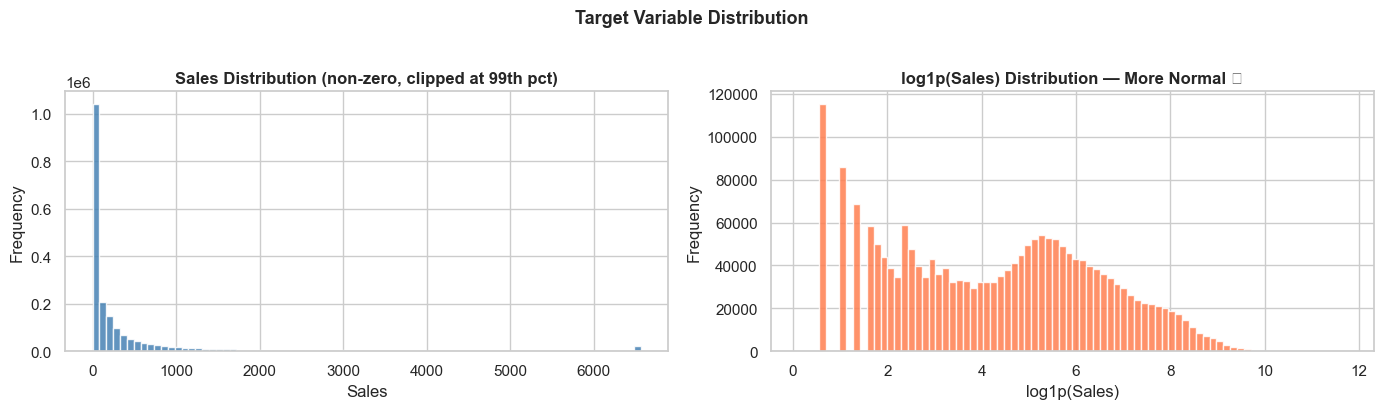

In [9]:
# — Sales Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution (excluding zeros for clarity)
nonzero = train_df[train_df['sales'] > 0]['sales']
axes[0].hist(nonzero.clip(upper=nonzero.quantile(0.99)),
             bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Sales Distribution (non-zero, clipped at 99th pct)',
                  fontweight='bold')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Log-transformed
axes[1].hist(np.log1p(nonzero), bins=80,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('log1p(Sales) Distribution — More Normal ✅',
                  fontweight='bold')
axes[1].set_xlabel('log1p(Sales)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Distribution', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/sales_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

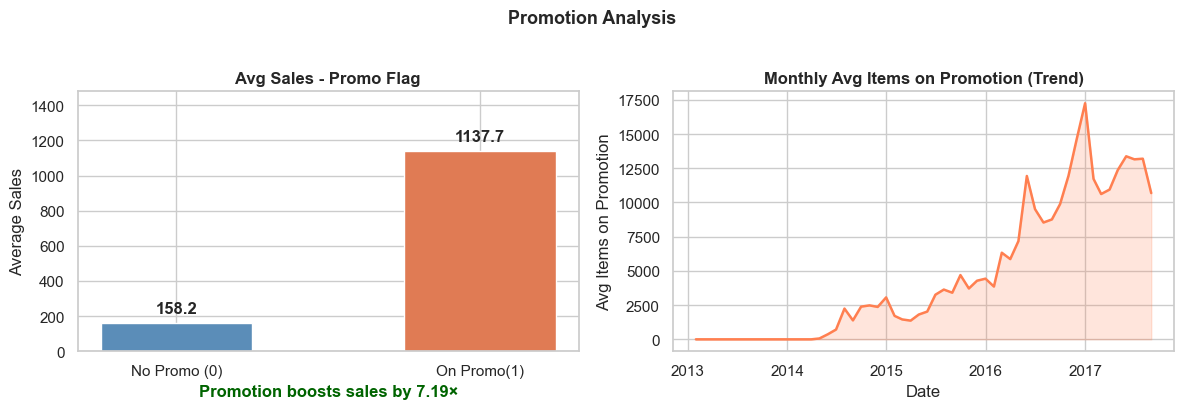

💡 Items on promotion sell 7.19× more on average


In [10]:
# Promotion Impact on Sales

promo_avg = train_df.groupby('onpromotion')['sales'].mean().round()

train_df['promo_flag'] = (train_df['onpromotion'] > 0).astype(int)
promo_flag_avg = train_df.groupby('promo_flag')['sales'].mean().round(2)

fig, axes = plt.subplots(1,2, figsize=(12,4))

bars1 = axes[0].bar(['No Promo (0)', 'On Promo(1)'],
                    promo_flag_avg.values,
                    color=['#5b8db8', '#e07b54'],
                    edgecolor ='white', width=0.5)
axes[0].bar_label(bars1, fmt='%.1f', padding=5, fontweight='bold')
axes[0].set_title('Avg Sales - Promo Flag',  fontweight='bold')
axes[0].set_ylabel('Average Sales')
boost = promo_flag_avg[1] / promo_flag_avg[0]
axes[0].set_xlabel(f'Promotion boosts sales by {boost:.2f}×',
                   color='darkgreen', fontweight='bold')
axes[0].set_ylim(0, promo_flag_avg.max() * 1.3)

# Promo trend over time
promo_trend =(train_df.groupby('date')['onpromotion']
              .sum()
              .resample('ME')
              .mean()
              .reset_index())
axes[1].plot(promo_trend['date'], promo_trend['onpromotion'],
             color='coral', linewidth=1.8)
axes[1].fill_between(promo_trend['date'], promo_trend['onpromotion'],
                     alpha=0.2, color='coral')
axes[1].set_title('Monthly Avg Items on Promotion (Trend)',
                  fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Avg Items on Promotion')

plt.suptitle('Promotion Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/promotion_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'💡 Items on promotion sell {boost:.2f}× more on average')


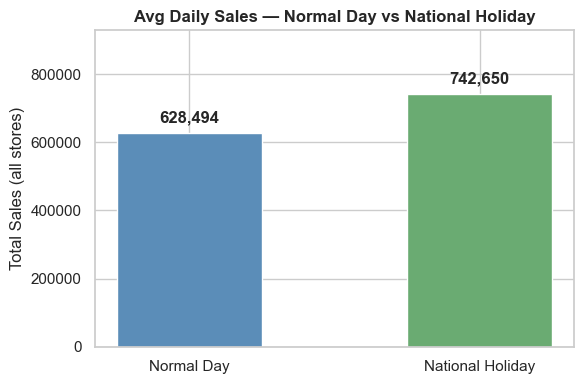

Holiday types found: {'Holiday': 221, 'Event': 56, 'Additional': 51, 'Transfer': 12, 'Bridge': 5, 'Work Day': 5}


In [11]:
# Holiday Impact on Sales

national_hol = hol_df[hol_df['locale'] == 'National'][['date', 'type', 'description']].copy()
national_hol['is_holiday'] = 1

daily_hol = (daily_sales
             .merge(national_hol[['date','is_holiday']], on='date', how='left'))
daily_hol['is_holiday'] = daily_hol['is_holiday'].fillna(0)

hol_avg    = daily_hol.groupby('is_holiday')['sales'].mean().round(0)
hol_labels = ['Normal Day', 'National Holiday']

plt.figure(figsize=(6, 4))
bars = plt.bar(hol_labels, hol_avg.values,
               color=['#5b8db8', '#6aab72'], edgecolor='white', width=0.5)
plt.bar_label(bars,
              labels=[f'{v:,.0f}' for v in hol_avg.values],
              padding=5, fontweight='bold')
plt.title('Avg Daily Sales — Normal Day vs National Holiday',
          fontweight='bold')
plt.ylabel('Total Sales (all stores)')
plt.ylim(0, hol_avg.max() * 1.25)
plt.tight_layout()
plt.savefig('data/processed/holiday_impact.png', dpi=100, bbox_inches='tight')
plt.show()
print('Holiday types found:', hol_df['type'].value_counts().to_dict())

### — Store Type & Cluster Analysis

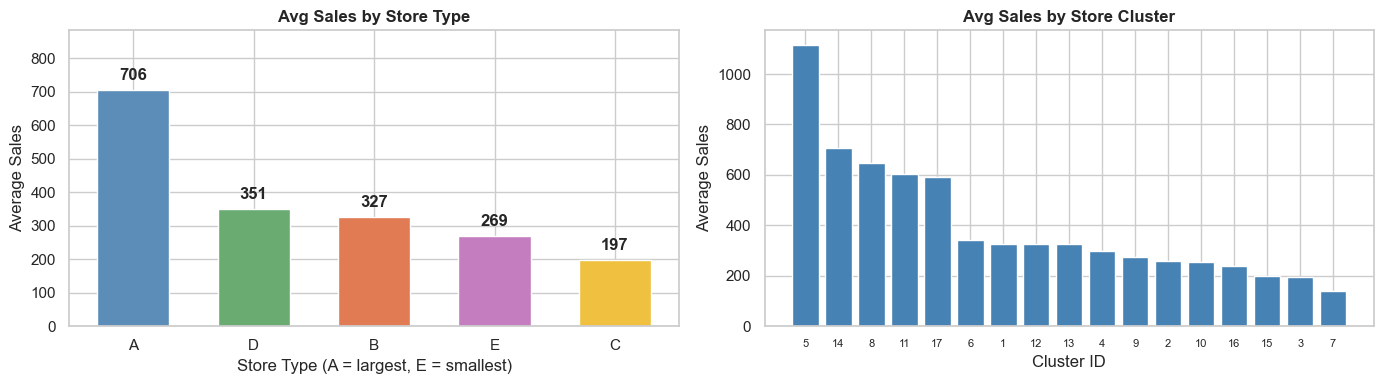

In [12]:
train_store = train_df.merge(stores_df, on='store_nbr', how='left')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By store type
type_avg = (train_store.groupby('type')['sales']
            .mean()
            .sort_values(ascending=False))
colors_t = ['#5b8db8','#6aab72','#e07b54','#c47ec0','#f0c040']
bars1 = axes[0].bar(type_avg.index, type_avg.values,
                    color=colors_t, edgecolor='white', width=0.6)
axes[0].bar_label(bars1, fmt='%.0f', padding=5, fontweight='bold')
axes[0].set_title('Avg Sales by Store Type', fontweight='bold')
axes[0].set_xlabel('Store Type (A = largest, E = smallest)')
axes[0].set_ylabel('Average Sales')
axes[0].set_ylim(0, type_avg.max() * 1.25)

# By cluster
cluster_avg = (train_store.groupby('cluster')['sales']
               .mean()
               .sort_values(ascending=False)
               .reset_index())
axes[1].bar(cluster_avg['cluster'].astype(str), cluster_avg['sales'],
            color='steelblue', edgecolor='white')
axes[1].set_title('Avg Sales by Store Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Average Sales')
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('data/processed/store_type_cluster.png', dpi=100, bbox_inches='tight')
plt.show()


### — Year-over-Year Sales Growth

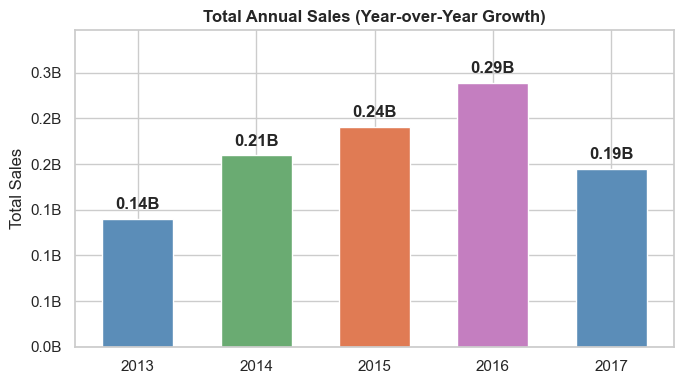

In [13]:
yearly = train_df.groupby('year')['sales'].sum().reset_index()
yearly = yearly[yearly['year'] < 2027]
plt.figure(figsize=(7, 4))
bars = plt.bar(yearly['year'].astype(str), yearly['sales'],
               color=['#5b8db8','#6aab72','#e07b54','#c47ec0'],
               edgecolor='white', width=0.6)
plt.bar_label(bars,
              labels=[f'{v/1e9:.2f}B' for v in yearly['sales']],
              padding=5, fontweight='bold')
plt.title('Total Annual Sales (Year-over-Year Growth)',
          fontweight='bold')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
plt.ylim(0, yearly['sales'].max() * 1.2)
plt.tight_layout()
plt.savefig('data/processed/yoy_growth.png', dpi=100, bbox_inches='tight')
plt.show()

### — Correlation Heatmap

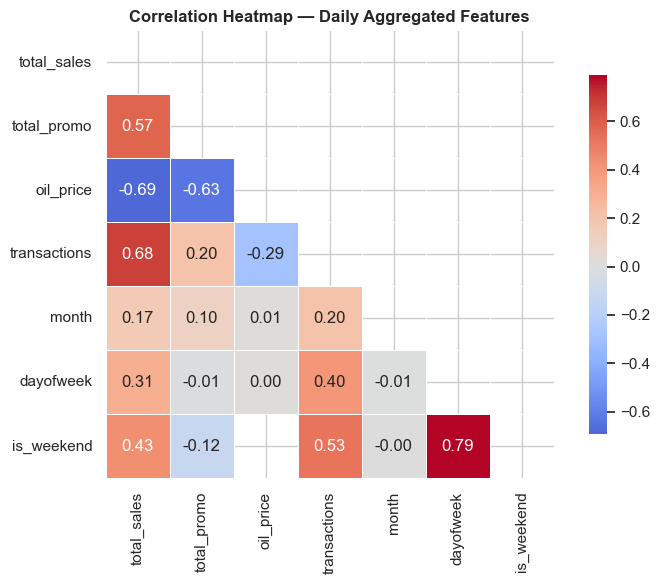

In [14]:
# Build a daily aggregate for correlation analysis
daily_agg = (train_df.groupby('date')
             .agg(total_sales =('sales',sum),
                  total_promo=('onpromotion', 'sum'),
                  promo_items=('promo_flag', 'sum'))
                .reset_index()
                .merge(oil_df.rename(columns={'dcoilwtico':'oil_price'}),
                       on='date',how='left')
                .merge(txn_df.groupby('date')['transactions'].sum().reset_index(),
                    on='date', how='left'))

daily_agg['month']      = daily_agg['date'].dt.month
daily_agg['dayofweek']  = daily_agg['date'].dt.dayofweek
daily_agg['is_weekend'] = (daily_agg['dayofweek'] >= 5).astype(int)

corr_cols = ['total_sales','total_promo','oil_price',
             'transactions','month','dayofweek','is_weekend']
corr = daily_agg[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Daily Aggregated Features',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

###  Time-Series Decomposition

We break daily sales into **4 components** to understand the underlying structure:

| Component | What it shows |
|---|---|
| **Observed** | Raw daily sales signal |
| **Trend** | Long-term growth or decline direction |
| **Seasonal** | Repeating weekly pattern (period = 7 days) |
| **Residual** | Unexplained noise (holidays, promotions, 

Daily Series: 1688 days |2013-01-01 2017-08-15
 Missing dates: 0


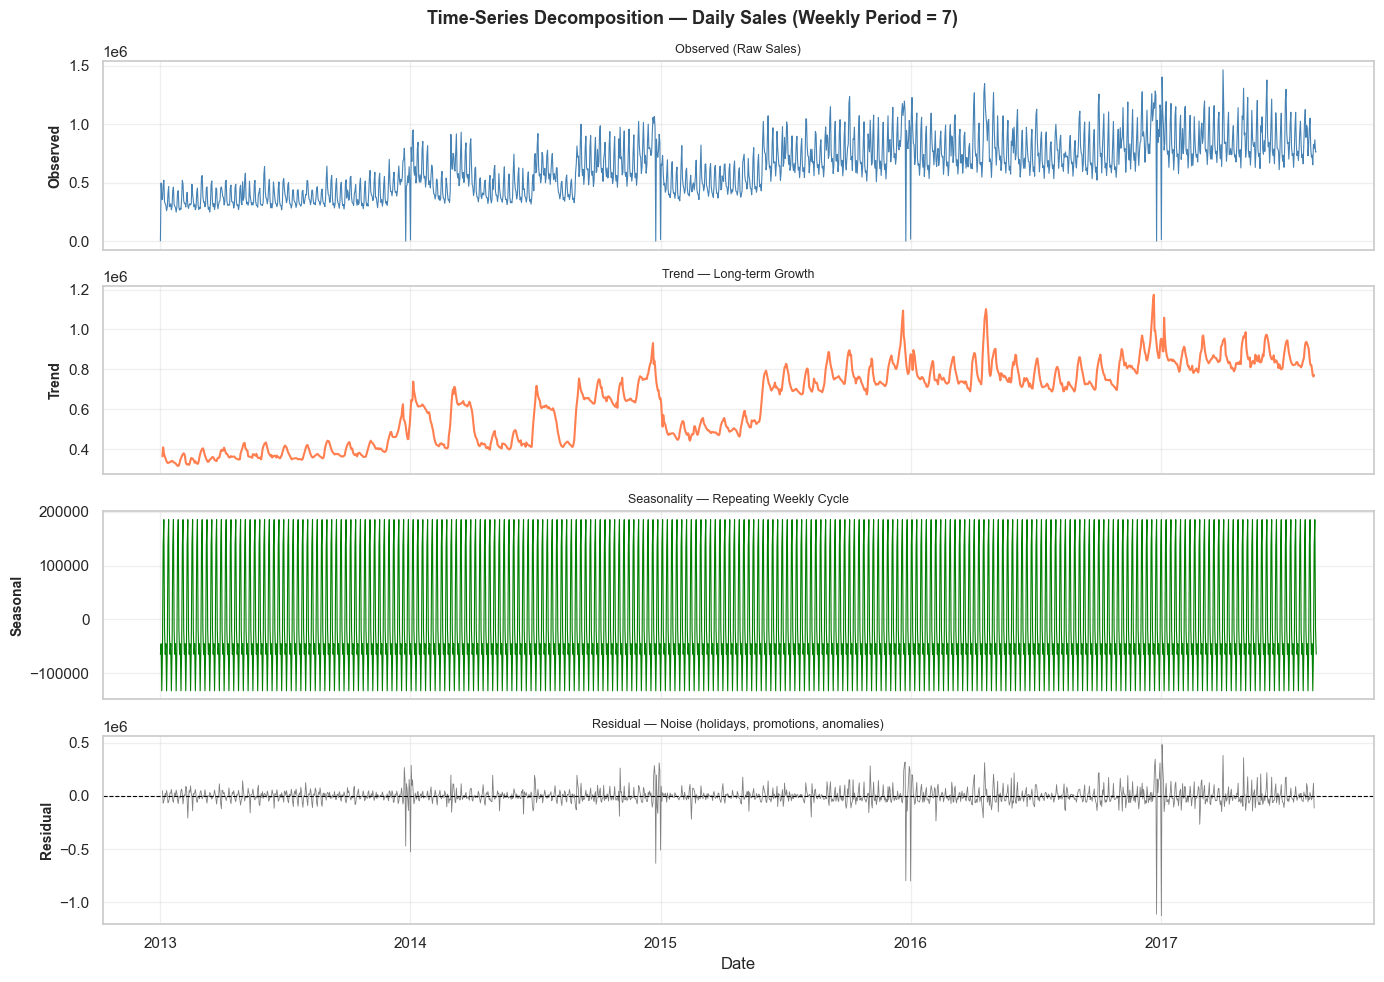


💡 Observation:
   Trend   → Steady upward growth from 2013 to 2017
   Seasonal → Clear weekly cycle — demand repeats every 7 days
   Residual → Large spikes = holidays / promotions not in the weekly pattern


In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Aggregate train to daily total sales
daily_series = train_df.groupby("date")["sales"].sum()

# Set daily frequency — fill any missing dates with 0
daily_series = daily_series.asfreq("D",fill_value=0)
print(f"Daily Series: {len(daily_series)} days |" 
      f"{daily_series.index.min().date()} {daily_series.index.max().date()}")
print(f" Missing dates: {daily_series.isnull().sum()}")

# Decompose — additive model (trend + seasonal + residual)
result = seasonal_decompose(daily_series, model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Time-Series Decomposition — Daily Sales (Weekly Period = 7)",
             fontsize=13, fontweight="bold")

axes[0].plot(result.observed,  color="steelblue", lw=0.8)
axes[0].set_ylabel("Observed",  fontsize=10, fontweight="bold")
axes[0].set_title("Observed (Raw Sales)", fontsize=9)

axes[1].plot(result.trend,     color="coral",     lw=1.5)
axes[1].set_ylabel("Trend",     fontsize=10, fontweight="bold")
axes[1].set_title("Trend — Long-term Growth", fontsize=9)

axes[2].plot(result.seasonal,  color="green",     lw=0.8)
axes[2].set_ylabel("Seasonal",  fontsize=10, fontweight="bold")
axes[2].set_title("Seasonality — Repeating Weekly Cycle", fontsize=9)

axes[3].plot(result.resid,     color="gray",      lw=0.6)
axes[3].axhline(0, color="black", lw=0.8, linestyle="--")
axes[3].set_ylabel("Residual",  fontsize=10, fontweight="bold")
axes[3].set_title("Residual — Noise (holidays, promotions, anomalies)", fontsize=9)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("data/processed/time_series_decomposition.png", dpi=100, bbox_inches="tight")
plt.show()

print("")
print("💡 Observation:")
print("   Trend   → Steady upward growth from 2013 to 2017")
print("   Seasonal → Clear weekly cycle — demand repeats every 7 days")
print("   Residual → Large spikes = holidays / promotions not in the weekly pattern")




### 📊 Autocorrelation Plot (ACF & PACF)

Autocorrelation tells us **how much past sales influence future sales**:

| **ACF** (Autocorrelation Function) | Correlation between sales today and sales N days ago (includes indirect effects) |
| **PACF** (Partial Autocorrelation) | Direct effect of each lag after removing shorter lags |

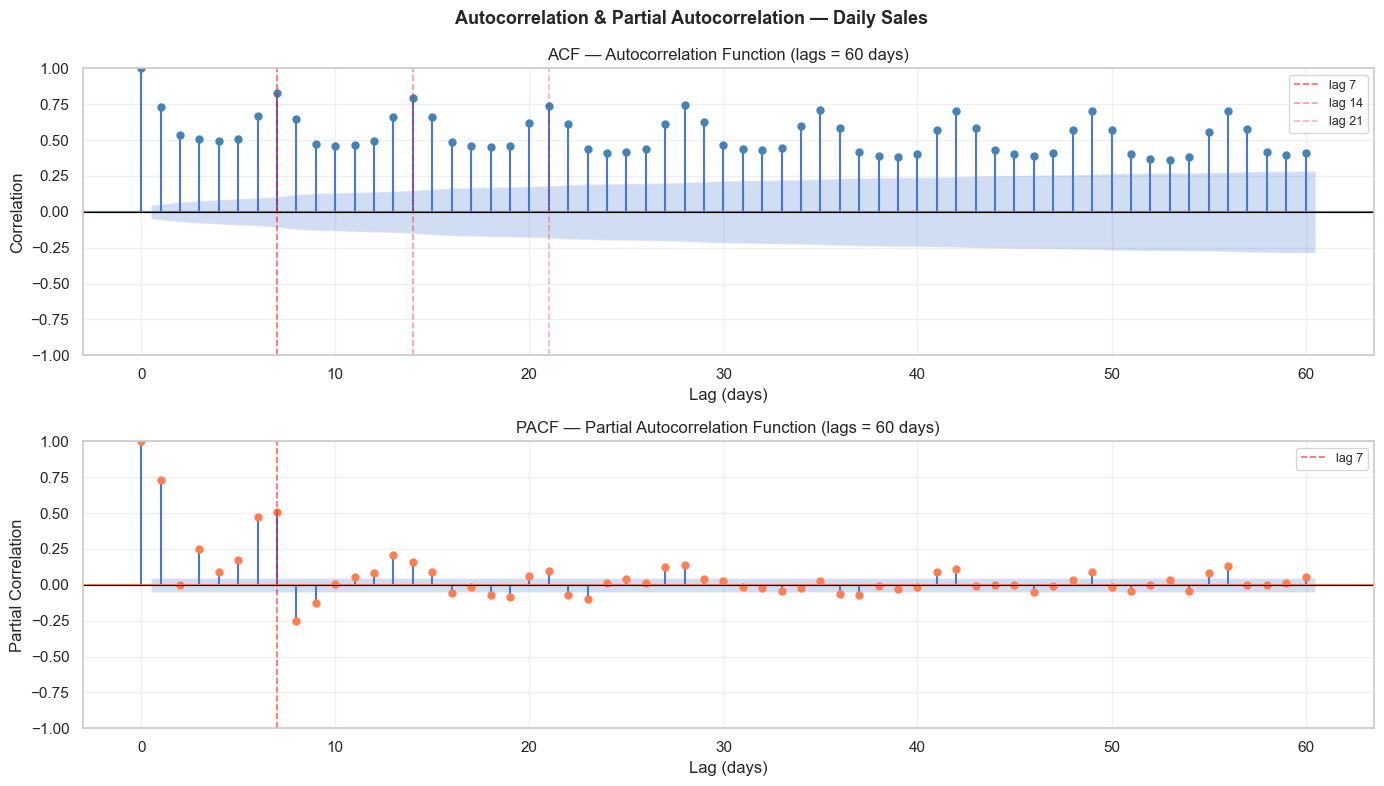

In [19]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf


fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Autocorrelation & Partial Autocorrelation — Daily Sales",
             fontsize=13, fontweight="bold")
# --- ACF Plot ---
plot_acf(daily_series, lags=60, ax=axes[0], color="steelblue",
         title="ACF — Autocorrelation Function (lags = 60 days)")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Correlation")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axvline(7,  color="red", lw=1.2, linestyle="--", alpha=0.6, label="lag 7")
axes[0].axvline(14, color="red", lw=1.2, linestyle="--", alpha=0.4, label="lag 14")
axes[0].axvline(21, color="red", lw=1.2, linestyle="--", alpha=0.3, label="lag 21")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- PACF Plot ---
plot_pacf(daily_series, lags=60, ax=axes[1], color="coral",
          title="PACF — Partial Autocorrelation Function (lags = 60 days)")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Partial Correlation")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axvline(7,  color="red", lw=1.2, linestyle="--", alpha=0.6, label="lag 7")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/acf_pacf.png", dpi=100, bbox_inches="tight")
plt.show()


### Merge All Files into Master DataFrame

In [20]:
# National holiday flag

nat_hol = ( hol_df[hol_df['locale'] == 'National'][['date']]
           .drop_duplicates()
           .assign(is_national_holiday=1))

# Build Master DataFrame
master = (
    train_df
    .merge(stores_df,  on='store_nbr',           how='left')   # store metadata
    .merge(oil_df,     on='date',                how='left')   # oil price
    .merge(txn_df,     on=['date','store_nbr'],  how='left')   # transactions
    .merge(nat_hol,    on='date',                how='left')   # holiday flag
)

# Fill holiday flag 0 where not a holiday

master['is_national_holiday'] = master['is_national_holiday'].fillna(0).astype(int)

# Rename oil column
master.rename(columns={'dcoilwtico': 'oil_price'}, inplace=True)

# date features
master['year']        = master['date'].dt.year
master['month']       = master['date'].dt.month
master['day']         = master['date'].dt.day
master['dayofweek']   = master['date'].dt.dayofweek   # 0=Mon, 6=Sun
master['is_weekend']  = (master['dayofweek'] >= 5).astype(int)
master['promo_flag']  = (master['onpromotion'] > 0).astype(int)

print(f'✅ Master DataFrame shape: {master.shape[0]:,} rows × {master.shape[1]} columns')
print(f'   Columns: {list(master.columns)}')
print(f'\nMissing values in master:')
print(master.isnull().sum()[master.isnull().sum() > 0])
display(master.head())

    

✅ Master DataFrame shape: 3,000,888 rows × 19 columns
   Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'month', 'year', 'dayofweek', 'promo_flag', 'city', 'state', 'type', 'cluster', 'oil_price', 'transactions', 'is_national_holiday', 'day', 'is_weekend']

Missing values in master:
oil_price       858924
transactions    245784
dtype: int64


,id,date,store_nbr,family,sales,onpromotion,month,year,dayofweek,promo_flag,city,state,type,cluster,oil_price,transactions,is_national_holiday,day,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0


### ✂️Train / Validation / Test Split

In [23]:
TRAIN_END = '2016-12-31'
VAL_END   = '2017-05-31'


df_train = master[master['date'] <= TRAIN_END].copy()
df_val   = master[(master['date'] > TRAIN_END) & (master['date'] <= VAL_END)].copy()
df_test  = master[master['date'] > VAL_END].copy()

total = len(master)
print('✅ Sequential Split Complete')
print('=' * 56)
print(f"  {'Split':<12} {'Date Range':<28} {'Rows':>8}  {'%':>6}")
print('-' * 56)
print(f"  {'Train':<12} {'2013-01-01  →  2016-12-31':<28} {len(df_train):>8,}  {len(df_train)/total*100:>5.1f}%")
print(f"  {'Validation':<12} {'2017-01-01  →  2017-05-31':<28} {len(df_val):>8,}  {len(df_val)/total*100:>5.1f}%")
print(f"  {'Test':<12} {'2017-06-01  →  2017-08-15':<28} {len(df_test):>8,}  {len(df_test)/total*100:>5.1f}%")
print('=' * 56)
print(f"  {'Total':<12} {'':28} {total:>8,}  100.0%")


✅ Sequential Split Complete
  Split        Date Range                       Rows       %
--------------------------------------------------------
  Train        2013-01-01  →  2016-12-31    2,596,374   86.5%
  Validation   2017-01-01  →  2017-05-31     269,082    9.0%
  Test         2017-06-01  →  2017-08-15     135,432    4.5%
  Total                                     3,000,888  100.0%


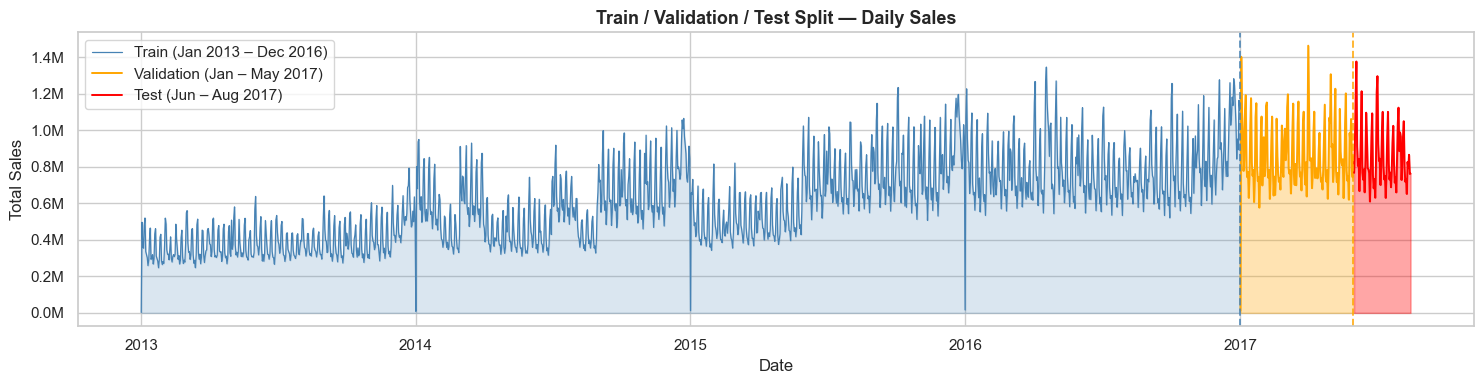

In [24]:
# Visualise the split on the daily sales chart
daily_sales = master.groupby('date')['sales'].sum().reset_index()

train_d = daily_sales[daily_sales['date'] <= TRAIN_END]
val_d   = daily_sales[(daily_sales['date'] > TRAIN_END) & (daily_sales['date'] <= VAL_END)]
test_d  = daily_sales[daily_sales['date'] > VAL_END]

plt.figure(figsize=(15, 4))

plt.fill_between(train_d['date'], train_d['sales'],
                 alpha=0.20, color='steelblue')
plt.plot(train_d['date'], train_d['sales'],
         color='steelblue', linewidth=0.9, label='Train (Jan 2013 – Dec 2016)')

plt.fill_between(val_d['date'], val_d['sales'],
                 alpha=0.30, color='orange')
plt.plot(val_d['date'], val_d['sales'],
         color='orange', linewidth=1.4, label='Validation (Jan – May 2017)')

plt.fill_between(test_d['date'], test_d['sales'],
                 alpha=0.35, color='red')
plt.plot(test_d['date'], test_d['sales'],
         color='red', linewidth=1.4, label='Test (Jun – Aug 2017)')

plt.axvline(pd.Timestamp(TRAIN_END), color='steelblue',
            linestyle='--', linewidth=1.4, alpha=0.8)
plt.axvline(pd.Timestamp(VAL_END), color='orange',
            linestyle='--', linewidth=1.4, alpha=0.8)

plt.title('Train / Validation / Test Split — Daily Sales',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('data/processed/train_val_test_split.png', dpi=100, bbox_inches='tight')
plt.show()

In [25]:
# Sales statistics per split — verify no distribution shift
stats = pd.DataFrame({
    'Split'  : ['Train', 'Validation', 'Test'],
    'Rows'   : [len(df_train), len(df_val), len(df_test)],
    'Mean'   : [df_train['sales'].mean(), df_val['sales'].mean(), df_test['sales'].mean()],
    'Std'    : [df_train['sales'].std(),  df_val['sales'].std(),  df_test['sales'].std()],
    'Min'    : [df_train['sales'].min(),  df_val['sales'].min(),  df_test['sales'].min()],
    'Max'    : [df_train['sales'].max(),  df_val['sales'].max(),  df_test['sales'].max()],
    'Zero %' : [f"{(df_train['sales']==0).mean()*100:.1f}%",
                f"{(df_val['sales']==0).mean()*100:.1f}%",
                f"{(df_test['sales']==0).mean()*100:.1f}%"],
}).round(2)

print('Sales statistics per split:')
display(stats)
print('\n✅ Distribution is consistent across splits — safe to proceed to modelling')

Sales statistics per split:


,Split,Rows,Mean,Std,Min,Max,Zero %
0,Train,2596374,338.71,1055.83,0.0,124717.00,33.8%
1,Validation,269082,479.74,1366.40,0.0,38422.62,15.4%
2,Test,135432,480.89,1332.65,0.0,24744.00,14.4%



✅ Distribution is consistent across splits — safe to proceed to modelling


In [26]:
os.makedirs('data/processed', exist_ok=True)

master.to_csv('data/processed/master_df.csv',       index=False)
df_train.to_csv('data/processed/train_split.csv',   index=False)
df_val.to_csv('data/processed/val_split.csv',       index=False)
df_test.to_csv('data/processed/test_split.csv',     index=False)

print('✅ All files saved to data/processed/')
print()
print('  master_df.csv    — full merged dataset  :', f'{len(master):,} rows')
print('  train_split.csv  — 2013-01-01 → 2016-12-31 :', f'{len(df_train):,} rows')
print('  val_split.csv    — 2017-01-01 → 2017-05-31 :', f'{len(df_val):,} rows')
print('  test_split.csv   — 2017-06-01 → 2017-08-15 :', f'{len(df_test):,} rows')

✅ All files saved to data/processed/

  master_df.csv    — full merged dataset  : 3,000,888 rows
  train_split.csv  — 2013-01-01 → 2016-12-31 : 2,596,374 rows
  val_split.csv    — 2017-01-01 → 2017-05-31 : 269,082 rows
  test_split.csv   — 2017-06-01 → 2017-08-15 : 135,432 rows
